# Exploratory Data Analysis (EDA)

Project: Trade, Policy, and Carbon — Assessing Globalisation in Climate Agreements

Project Goal 
<br> This project looks at whether strict domestic environmental laws actually cut global carbon footprints, or if they just push emissions overseas through international trade (a process known as carbon leakage).
<br>
<br> The analysis centers on four major European economies (France, Germany, the Netherlands, and the United Kingdom) between 2010 and 2022.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
co2 = pd.read_csv("../data/owid-co2-data.csv")
trade = pd.read_csv("../data/trade_percent_gdp.csv", skiprows=4)

In [3]:
# Clean CO2 data
countries = ["United Kingdom", "Germany", "France", "Netherlands"]

co2 = co2[
    (co2["country"].isin(countries)) &
    (co2["year"].between(2010, 2022))
][["country", "year", "co2", "consumption_co2"]]

co2 = co2.dropna()

# Calculate the Emissions Gap
# A positive number means a country imports more carbon than it produces domestically
co2["emissions_gap"] = co2["consumption_co2"] - co2["co2"]

# Clean trade data
# Keep only year columns
year_cols = [col for col in trade.columns if col.isdigit()]
trade = trade[["Country Name"] + year_cols]

# Melt from wide to long format
trade = trade.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="trade_percent_gdp"
)

trade["year"] = trade["year"].astype(int)
trade["country"] = trade["Country Name"]

trade = trade[["country", "year", "trade_percent_gdp"]]

# Combine datasets into a single clean table
df = pd.merge(co2, trade, on=["country", "year"], how="left")

## Key Visualisations

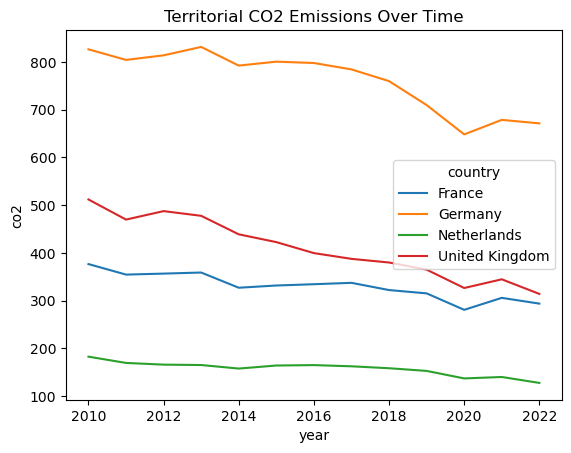

In [4]:
# 1. Terrirotial Emissions over Time
sns.lineplot(data=df, x="year", y="co2", hue="country")
plt.title("Territorial CO2 Emissions Over Time")
plt.show()

On paper, all four countries look like climate success stories. Their local factories and power plants are steadily cutting down emissions year over year.

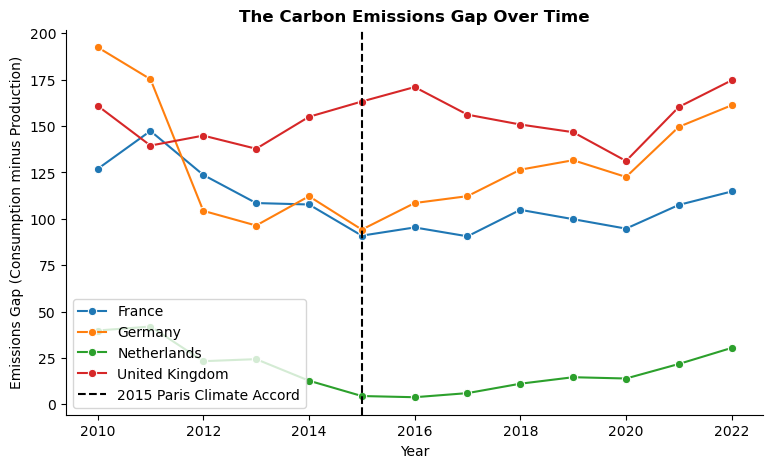

In [10]:
# 2. The Emissions Gap & The 2015 Policy Shift
plt.figure(figsize=(9, 5))
sns.lineplot(data=df, x="year", y="emissions_gap", hue="country", marker="o")
plt.axvline(
    2015,
    linestyle="--",
    color="black",
    label="2015 Paris Climate Accord",
)
plt.title("The Carbon Emissions Gap Over Time", weight="bold")
plt.xlabel("Year")
plt.ylabel("Emissions Gap (Consumption minus Production)")
plt.legend()
sns.despine()
plt.show()


Look at what happens right after the 2015 Paris Climate Agreement. The downward trend stops, and the gap starts rising across the board. As domestic environmental rules grew stricter, these economies began importing more carbon-intensive goods from abroad to meet consumer demand. The sharp drop in 2020 cleanly captures the temporary impact of COVID-19 lockdowns on global trade.

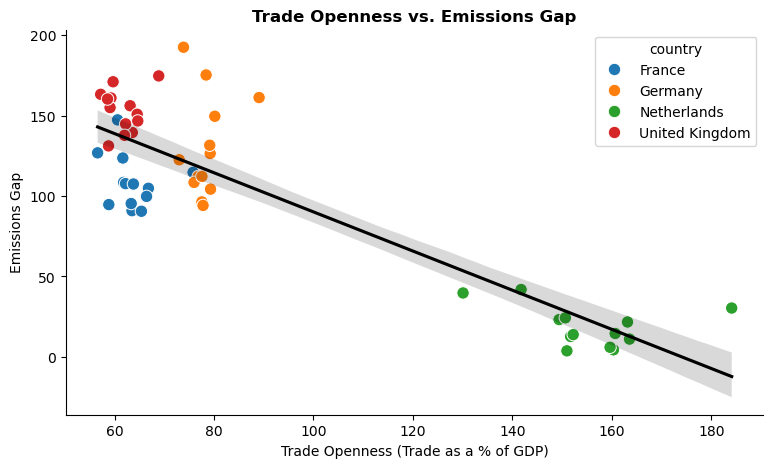

In [6]:
# 3. The Trade vs. Emissions Gap Relationship
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="trade_percent_gdp", y="emissions_gap", hue="country", s=80)
sns.regplot(data=df, x="trade_percent_gdp", y="emissions_gap", scatter=False, color="black")
plt.title("Trade Openness vs. Emissions Gap", weight="bold")
plt.xlabel("Trade Openness (Trade as a % of GDP)")
plt.ylabel("Emissions Gap")
sns.despine()
plt.show()

The overall trendline suggests that higher trade openness leads to a smaller carbon gap, which seems to contradict the carbon leakage theory. However, this line is entirely distorted by the Netherlands, which sits far to the right. Because of major shipping ports like Rotterdam, the Netherlands processes a massive amount of transit trade that doesn't actually reflect its local consumption.

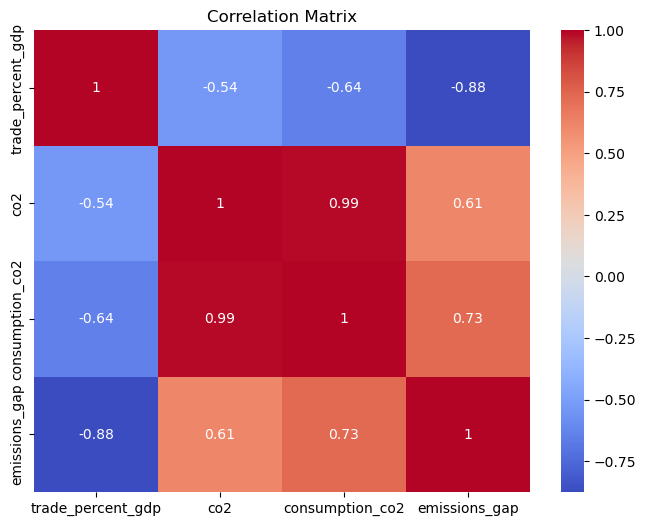

In [7]:
# 4. Cheacking for Overlapping Variables (Correlation Matrix)
corr = df[[
    "trade_percent_gdp",
    "co2",
    "consumption_co2",
    "emissions_gap"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Key Insights 
* **The Local Policy Illusion**: Evaluating a country's climate progress solely by what it produces domestically ignores the bigger picture. All four countries reduced local emissions while increasing their reliance on imported carbon.
<br>

* **The Post-2015 Turning Point**: The data reveals an important inflection point around the 2015 Paris Agreement. Tightening local emission caps directly correlates with an expansion of outsourced carbon footprints.
<br>

* **The "Rotterdam Effect" Trap**: The strong negative correlation (-0.88) between trade percentages and the emissions gap is a misleading statistical anomaly caused by mixing transit hubs like the Netherlands with destination consumer markets.
<br>

* **Data Redundancy**: Local production emissions and consumption emissions are almost perfectly correlated (0.99). Including both as independent variables in a standard linear regression will confuse the model and distort the results.

## Next Steps: Econometric Modelling
To address the data distortions identified during Exploratory Data Analysis (EDA), the modelling phase implements the following structural refinements:
1. Transition from Pooled OLS: The analysis moves beyond a basic combined regression line to account for the unique economic profiles of each country.
2. Implementation of Country Fixed-Effects: This isolates and controls for time-invariant structural trade traits, such as the "Rotterdam Effect" outlier in the Netherlands.
3. Variable De-escalation: Highly collinear or overlapping variables are removed to ensure model stability and coefficient accuracy.

> **Exporting Clean Panel Data for Modelling**
> <br> The cleaned and merged dataset to the `data/` directory so it can be loaded directly into our modelling and robustness notebooks.


In [8]:
# Save to csv file without the default numerical index column
df.to_csv("../data/clean_panel_data.csv", index=False)

# File verification check to confirm the file exists and saved properly
import os

print(
    "File saved successfully:",
    os.path.exists("../data/clean_panel_data.csv"),
)

File saved successfully: True
